In [3]:
import importlib
import src.ingestion
import src.preproc
import src.eda
import src.garch
importlib.reload(src.ingestion)
importlib.reload(src.preproc)
importlib.reload(src.eda)
importlib.reload(src.garch)
from src.ingestion import *
from src.preproc import *
from src.eda import *
from src.garch import *
unified = pd.read_csv(filepath_or_buffer=r"C:\Users\SHREY\Desktop\FM Final Project\insights\unified.csv")
global_df = unified.drop(columns=["ret_^NSEI", "vol_^NSEI", "ret_USDINR=X", "vol_USDINR=X"])

### Data Loading and Pre-processing

In [19]:
download_assets()

=== STEP 1.1: Asset Price Data Collection START ===
Saved → dataset\BTC-USD.csv
Saved → dataset\ETH-USD.csv
Saved → dataset\^GSPC.csv
Saved → dataset\^GSPTSE.csv
Saved → dataset\^HSI.csv
Saved → dataset\^BVSP.csv
Saved → dataset\^AXJO.csv
Saved → dataset\^NSEI.csv
Saved → dataset\GC=F.csv
Saved → dataset\USDINR=X.csv
Saved → dataset\CAD=X.csv
Saved → dataset\HKD=X.csv
Saved → dataset\BRL=X.csv
Saved → dataset\AUD=X.csv
=== STEP 1.1 COMPLETE ===


In [23]:
nan_summary = check_nan_across_files()
nan_summary.head()

=== NaN CHECK ACROSS ALL FILES ===

File: AUD=X.csv
Shape: (1561, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BRL=X.csv
Shape: (1561, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: BTC-USD.csv
Shape: (2191, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: CAD=X.csv
Shape: (1561, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: ETH-USD.csv
Shape: (2191, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: GC=F.csv
Shape: (1509, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: HKD=X.csv
Shape: (1561, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
--------------------------------------------------
File: USDINR=X.csv
Shape: (1561, 8)
Total NaNs: 0 (0.0000%)
No NaNs found.
-------------------------

,file,rows,cols,total_nans,nan_pct
0,AUD=X.csv,1561,8,0,0.0
1,BRL=X.csv,1561,8,0,0.0
2,BTC-USD.csv,2191,8,0,0.0
3,CAD=X.csv,1561,8,0,0.0
4,ETH-USD.csv,2191,8,0,0.0


In [24]:
calendar_summary = check_calendar_alignment()
calendar_summary.head()

=== CALENDAR ALIGNMENT CHECK ===

Global date range: 2020-01-01 → 2025-12-30
Total unique dates (union): 2191

Common dates across ALL assets: 1299
Overlap ratio: 0.5929

AUD=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------
BRL=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------
BTC-USD:
  available: 2191
  missing: 0 (0.00%)
----------------------------------------
CAD=X:
  available: 1561
  missing: 630 (28.75%)
  sample missing: [datetime.date(2020, 1, 4), datetime.date(2020, 1, 5), datetime.date(2020, 1, 11), datetime.date(2020, 1, 12), datetime.date(2020, 1, 18)]
----------------------------------------

,ticker,available_dates,missing_dates,missing_pct
12,^HSI,1475,716,32.679142
13,^NSEI,1485,706,32.222729
9,^BVSP,1494,697,31.811958
11,^GSPTSE,1505,686,31.309904
10,^GSPC,1507,684,31.218622


In [26]:
keep_common_dates()

=== KEEPING ONLY COMMON DATES ACROSS ALL ASSETS ===

Common dates retained: 1299
AUD=X: 1561 → 1299 rows
BRL=X: 1561 → 1299 rows
BTC-USD: 2191 → 1299 rows
CAD=X: 1561 → 1299 rows
ETH-USD: 2191 → 1299 rows
GC=F: 1509 → 1299 rows
HKD=X: 1561 → 1299 rows
USDINR=X: 1561 → 1299 rows
^AXJO: 1518 → 1299 rows
^BVSP: 1494 → 1299 rows
^GSPC: 1507 → 1299 rows
^GSPTSE: 1505 → 1299 rows
^HSI: 1475 → 1299 rows
^NSEI: 1485 → 1299 rows

=== ALL FILES NOW PERFECTLY ALIGNED ===


In [29]:
convert_all_to_inr()

=== CONVERTING ALL ASSETS TO INR ===

Processing BTC-USD...
✔ Converted BTC-USD to INR
Processing ETH-USD...
✔ Converted ETH-USD to INR
Processing GC=F...
✔ Converted GC=F to INR
Processing ^AXJO...
✔ Converted ^AXJO to INR
Processing ^BVSP...
✔ Converted ^BVSP to INR
Processing ^GSPC...
✔ Converted ^GSPC to INR
Processing ^GSPTSE...
✔ Converted ^GSPTSE to INR
Processing ^HSI...
✔ Converted ^HSI to INR
Processing ^NSEI...
✔ Converted ^NSEI to INR

=== ALL FILES CONVERTED TO INR ===


### EDA

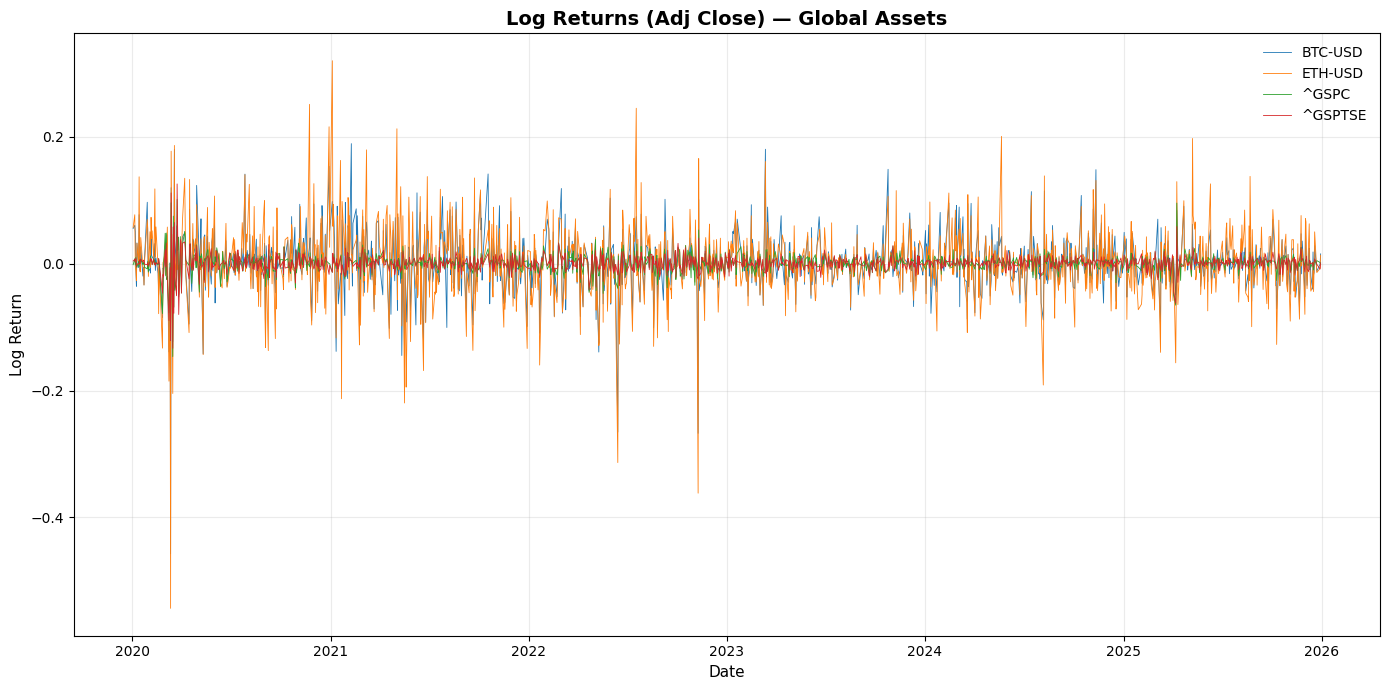

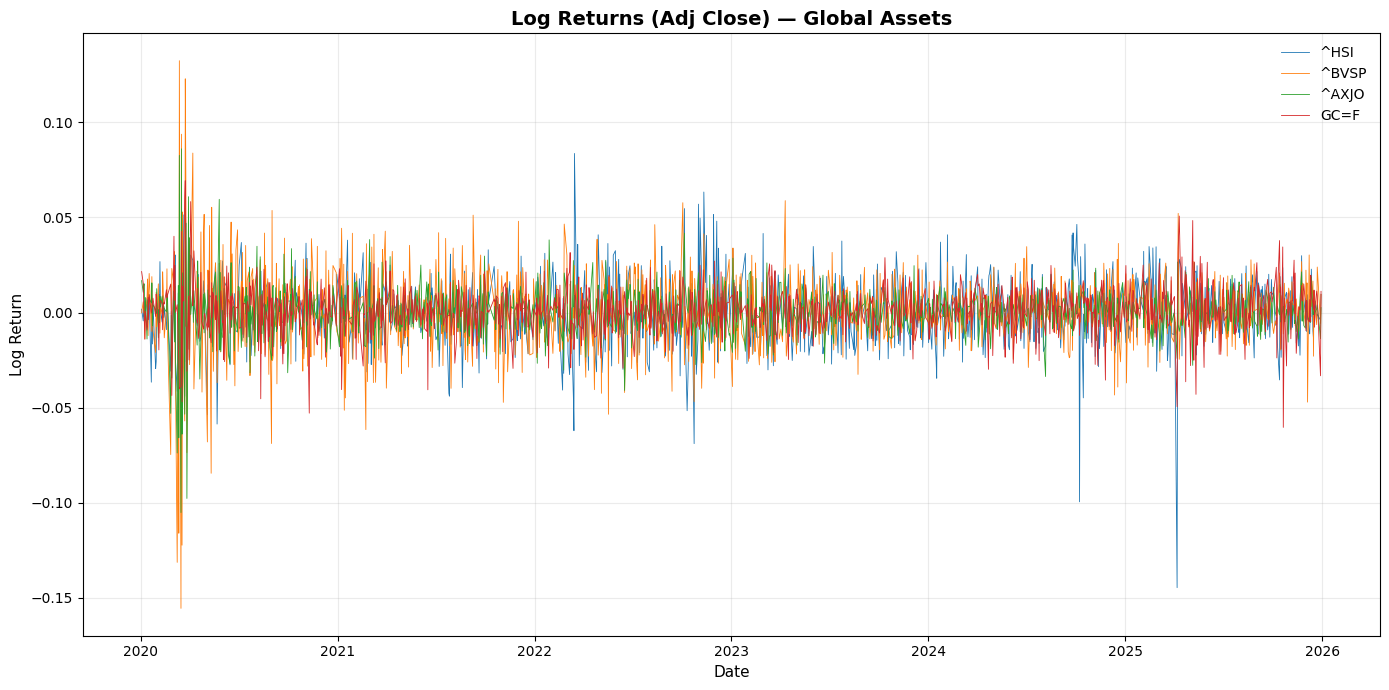

In [48]:
plot_global_log_returns(batch_size=4)

#### **Analysis of Global Asset Log Returns (2020–2026)**

The following points summarize the volatility and behavior of the assets shown in the provided log return plots. Log returns represent daily price changes, where a wider vertical spread indicates higher risk and volatility.

---

##### **Plot 1: Crypto vs. North American Indices**
*Focus: BTC-USD, ETH-USD, ^GSPC (S&P 500), ^GSPTSE (S&P/TSX Composite)*

* **Crypto Dominance in Volatility:** The cryptocurrencies (BTC and ETH) dwarf the equity indices in terms of daily swings. While the S&P 500 appears as a relatively thin line near zero, ETH (orange) and BTC (blue) frequently see swings exceeding +/- 10%.
* **The 2020 Liquidity Crunch:** All assets, including the equity indices, show their most significant synchronized spike in early 2020, marking the onset of the global pandemic.
* **Ethereum's Extremes:** ETH-USD displays the highest individual peaks and troughs in the dataset, including a massive downward spike in 2020 and high-activity clusters throughout 2021.
* **Index Stability:** The ^GSPC and ^GSPTSE show "tight" returns after 2020, suggesting that compared to crypto, North American equity markets remained remarkably stable despite various macroeconomic headwinds.

---

##### **Plot 2: International Indices and Gold**
*Focus: ^HSI (Hang Seng), ^BVSP (IBOVESPA), ^AXJO (ASX 200), GC=F (Gold)*

* **Regional Variance:** Unlike Plot 1, where assets behaved in distinct "classes," these assets share a similar volatility profile (the y-axis scale is much smaller, maxing out at ~0.15 vs ~0.50 in Plot 1).
* **Hang Seng Index (^HSI) Anomalies:** The blue line (^HSI) shows specific periods of decoupling, notably a significant downward spike in early 2025 that was not seen in the Australian (^AXJO) or Brazilian (^BVSP) markets.
* **Gold as a Safe Haven:** Gold (GC=F) remains the most consistently "compressed" line, staying closest to the zero-bound. It acts as a benchmark for low volatility compared to the equity indices.
* **Emerging Market Volatility:** The IBOVESPA (^BVSP) shows wider "spikes" than the ASX 200 (^AXJO), reflecting the typically higher risk/reward profile associated with the Brazilian market.

---

##### **Key Statistical Takeaways**
1.  **Volatility Clustering:** In both plots, periods of high volatility are followed by high volatility (the "bunched up" spikes), and quiet periods are followed by quiet periods.
2.  **Fat Tails:** The presence of long vertical spikes (outliers) confirms that these assets do not follow a perfect normal distribution; they are subject to "black swan" events.
3.  **Stationarity:** All series fluctuate around the 0.0 mean, which is the expected behavior for log returns in a long-term financial time series.

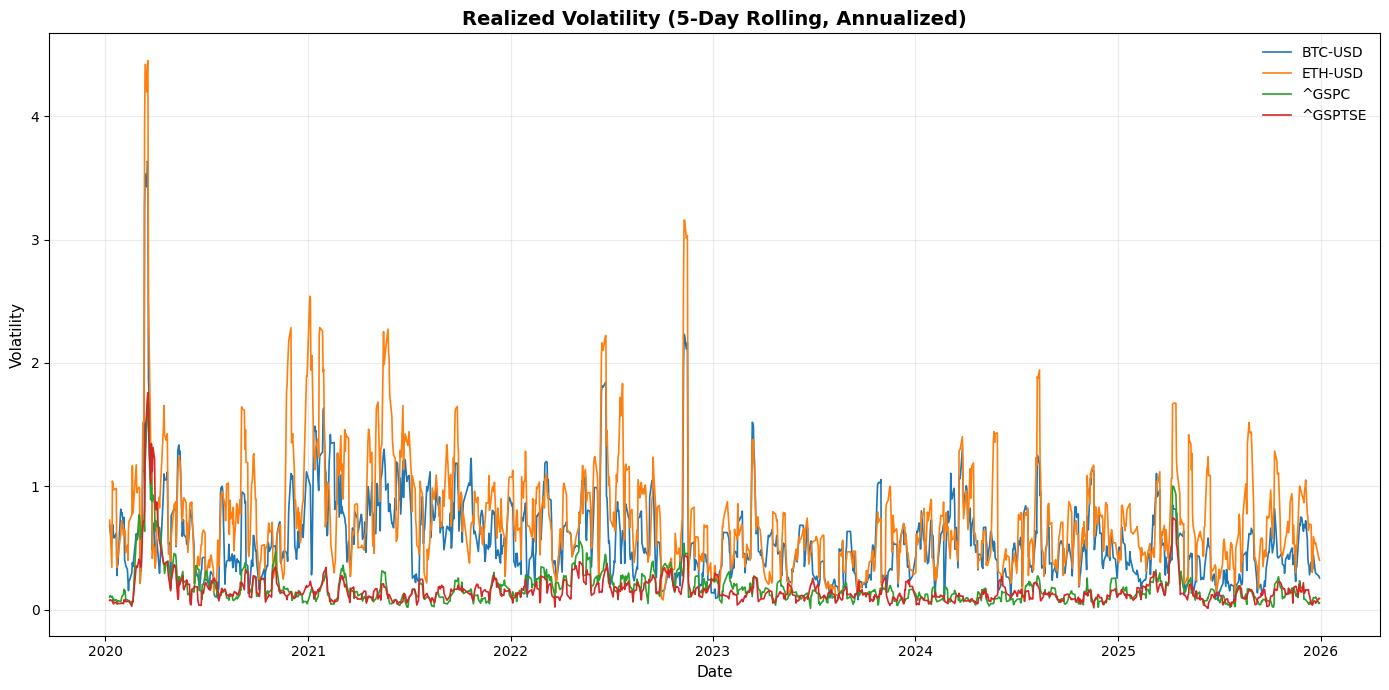

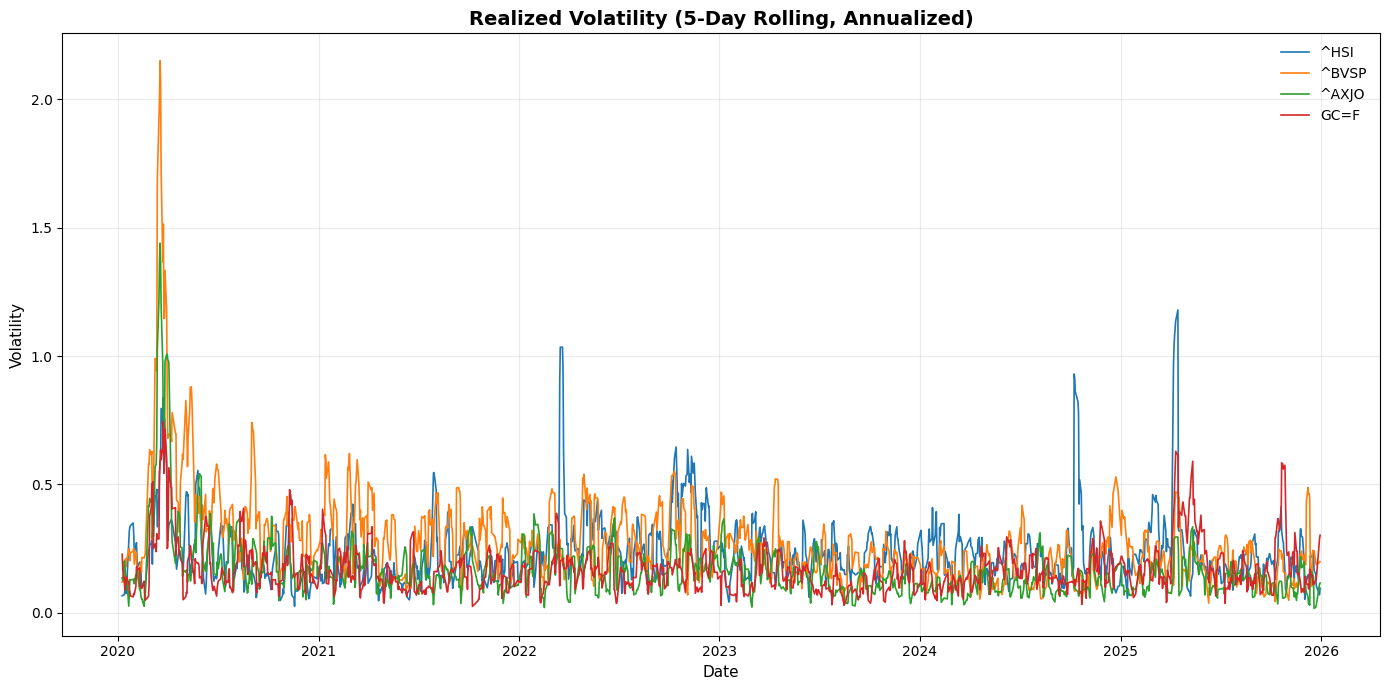

In [50]:
plot_realized_volatility(window=5, batch_size=4)

#### **Analysis of Realized Volatility (5-Day Rolling, Annualized)**

Realized volatility measures the standard deviation of returns over a moving window (5 days here), then annualizes it. Higher values indicate periods of intense price movement, while "peaks" represent market shocks.

---

##### **Plot 1: Crypto and North American Indices**
*Focus: BTC-USD, ETH-USD, ^GSPC, ^GSPTSE*

* **Extreme Crypto Volatility:** Ethereum (orange) and Bitcoin (blue) maintain a baseline volatility significantly higher than traditional stocks. While the S&P 500 (^GSPC) stays mostly below 0.5, ETH frequently spikes above 2.0, indicating extreme regime shifts.
* **The "Pandemic Peak":** In early 2020, all assets experienced a massive, synchronized volatility explosion. ETH reached its all-time high in this period, crossing the 4.0 threshold, reflecting a state of complete market panic.
* **Persistent Crypto Variance:** Throughout 2021 and 2022, crypto volatility stayed elevated and "jagged," whereas the equity indices settled quickly back into a low-volatility regime.
* **Recent Stability:** By 2025 and 2026, the gap between crypto and equity volatility has narrowed compared to previous years, though crypto still remains the riskier asset class by a factor of 2-3x.

---

##### **Plot 2: Global Indices and Gold**
*Focus: ^HSI, ^BVSP, ^AXJO, GC=F*

* **IBOVESPA (^BVSP) Volatility Leadership:** The Brazilian index (orange) consistently shows higher volatility spikes than its Australian (^AXJO) or Gold (GC=F) counterparts, especially during the 2020 crash and various periods in 2021.
* **Hang Seng (^HSI) Idiosyncratic Shocks:** The blue line exhibits unique spikes that don't correlate with the others—most notably the sharp rises in late 2024 and early 2025, suggesting region-specific market events.
* **Gold's Relative Calm:** Gold (red) typically maintains the lowest realized volatility in this group. However, it saw notable spikes in late 2025/early 2026, catching up to or exceeding the volatility of the equity indices for a brief period.
* **Synchronized Stress:** The plots clearly show that while assets have different baselines, they all "react" at the same time during major global events, such as the initial 2020 shock.

---

##### **Interpretation Key for .ipynb**
1. **Vertical Spikes:** These represent "shocks." A sharp vertical rise means the market was suddenly caught off guard by new information.
2. **Horizontal Baselines:** If a line stays flat and low, the asset is in a "quiet" period where prices are moving predictably.
3. **Decoupling:** When one line (like ^HSI in 2025) spikes while others stay flat, it indicates a localized crisis rather than a global one.


=== BTC-USD ===
Threshold: 0.9994
Crash days: 77
Saved flags → insights\crash_flags_BTC-USD.csv
Saved periods → insights\crash_periods_BTC-USD.csv


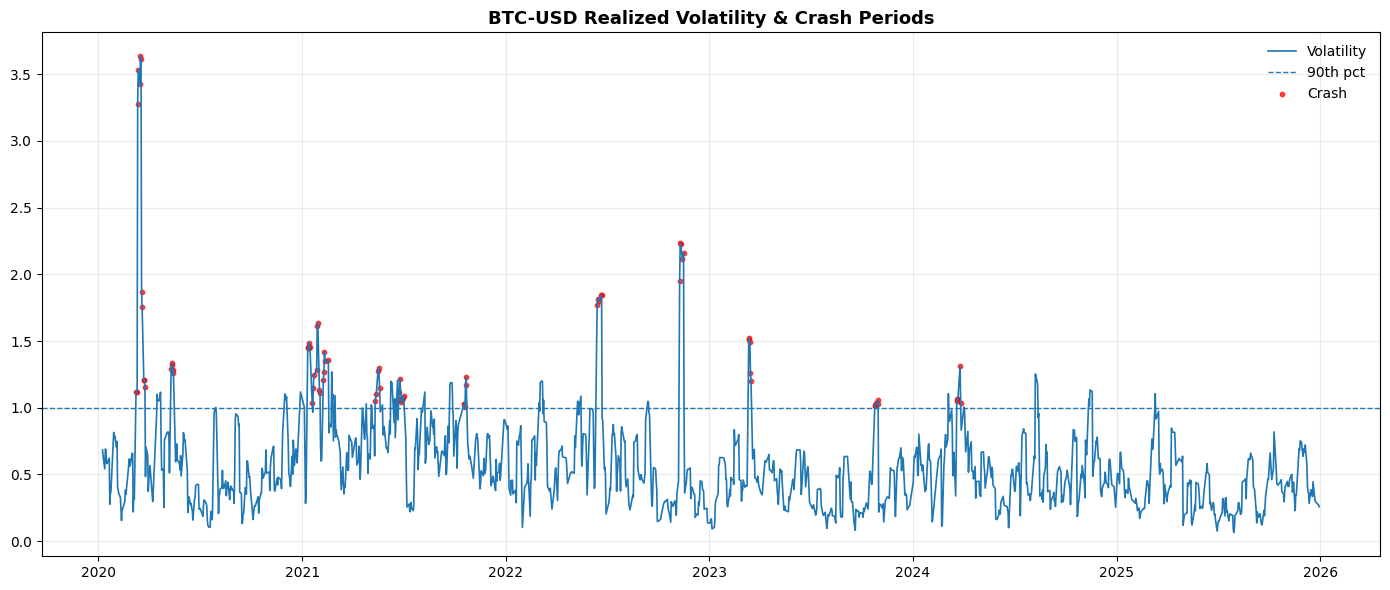


=== ETH-USD ===
Threshold: 1.2846
Crash days: 99
Saved flags → insights\crash_flags_ETH-USD.csv
Saved periods → insights\crash_periods_ETH-USD.csv


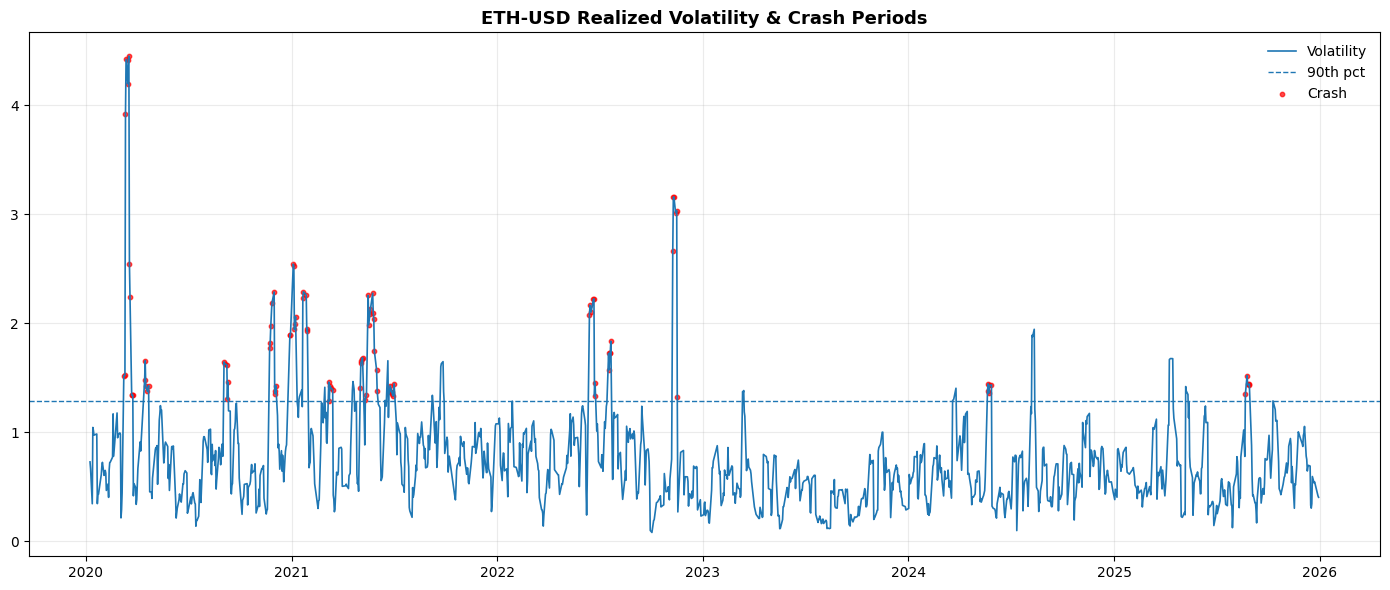


=== SUMMARY ===
     asset  threshold  crash_days  num_periods
0  BTC-USD   0.999426          77           13
1  ETH-USD   1.284572          99           15

Saved summary → insights\crash_summary.csv


In [58]:
summary, crash_periods = detect_crypto_crashes()

#### **Analysis of Realized Volatility & Crash Periods (BTC vs. ETH)**

This analysis uses a threshold-based approach (90th percentile) to identify "crash periods" where realized volatility significantly exceeds typical levels.

---

##### **Comparative Summary**

| Asset | Volatility Threshold | Total Crash Days | Number of Crash Periods |
| :--- | :--- | :--- | :--- |
| **BTC-USD** | 0.9994 | 77 | 13 |
| **ETH-USD** | 1.2846 | 99 | 15 |

*   **Higher Sensitivity in Ethereum:** ETH-USD has a higher volatility threshold (~1.28) compared to BTC (~1.00), indicating its "normal" baseline is more turbulent. Despite the higher bar, it still recorded more total crash days (99 vs. 77) and distinct crash periods (15 vs. 13).

---

##### **Key Observations from the Plots**

###### **BTC-USD Analysis**
*   **The 2020 Outlier:** The most extreme spike occurred in early 2020, with volatility peaking near 3.6, well above the 1.0 threshold.
*   **2021 Clusters:** Bitcoin saw frequent, shorter crash periods throughout 2021 (the "bull market" volatility). Sample periods show clusters lasting between 5 to 12 days.
*   **Late-Stage Stabilization:** Post-2023, Bitcoin's volatility frequently stays below the 1.0 threshold line, with only a few isolated red "crash" markers in 2024 and 2025.

###### **ETH-USD Analysis**
*   **Magnitude of Shocks:** Like Bitcoin, Ethereum's largest shock was in 2020, but it reached a much higher peak magnitude of ~4.5.
*   **Frequency of Breach:** The red dots (crash days) are more densely packed in ETH-USD, particularly in 2021 and early 2022. This suggests that when Ethereum "crashes," the volatility remains elevated for longer stretches.
*   **Recent Decoupling:** In late 2025, Ethereum shows a notable crash period that is more pronounced than the corresponding activity in Bitcoin, highlighting its higher idiosyncratic risk.

---

#### **Statistical Interpretation for ipynb**
*   **Thresholding:** The dashed blue line represents the 90th percentile of historical realized volatility. Any point above this line is statistically an outlier.
*   **Crash Days vs. Periods:** A "Crash Day" is a single data point above the threshold. A "Crash Period" is a contiguous sequence of these days. Ethereum's higher count in both metrics suggests it is more prone to sustained periods of extreme price instability.
*   **Risk Profile:** For developers and researchers, these plots illustrate that while BTC and ETH are correlated, ETH requires a much higher risk tolerance due to the frequency and magnitude of its volatility breaches.

In [60]:
unified = build_unified_matrix()

Saved unified matrix → insights\unified.csv

=== UNIFIED MATRIX INFO ===
(1294, 24)
        date  ret_BTC-USD  vol_BTC-USD  ret_ETH-USD  vol_ETH-USD  ret_^GSPC  \
0 2020-01-09    -0.035586     0.683925    -0.026686     0.726497  -0.003788   
1 2020-01-10     0.032785     0.637399     0.032186     0.661321  -0.005911   
2 2020-01-13    -0.006137     0.542621    -0.001571     0.342569   0.003557   
3 2020-01-14     0.077292     0.691047     0.137028     1.042803  -0.004821   
4 2020-01-15    -0.000571     0.684370     0.003441     1.015503   0.003651   

   vol_^GSPC  ret_^GSPTSE  vol_^GSPTSE  ret_^HSI  ...  vol_^AXJO  ret_^NSEI  \
0   0.101384    -0.003915     0.075426  0.006140  ...   0.136251   0.005300   
1   0.115031    -0.001123     0.082040 -0.001603  ...   0.125474   0.000291   
2   0.102508     0.000239     0.072513  0.007611  ...   0.202208   0.002523   
3   0.108391    -0.000620     0.072086 -0.005079  ...   0.178836  -0.000652   
4   0.074383     0.006125     0.058564 -0.0014

In [63]:
summary, periods = summarize_crash_overlap()


=== DAY-LEVEL SUMMARY ===
   btc_crash_days  eth_crash_days  overlap_days  btc_only_days  eth_only_days
0              77              99            39             38             60

=== SAMPLE EVENT PERIODS ===
       type      start        end  duration
0  btc_only 2020-05-11 2020-05-15         5
1  btc_only 2021-01-11 2021-01-15         5
2  btc_only 2021-01-19 2021-01-19         1
3  btc_only 2021-02-01 2021-02-02         2
4  btc_only 2021-02-08 2021-02-11         4

Saved → insights\crash_overlap_summary.csv
Saved → insights\crash_overlap_periods.csv


#### **Comparative Crash Analysis: BTC-USD vs. ETH-USD (2020–2026)**

This analysis explores the temporal relationship, duration, and frequency of "crash periods"—defined as days where realized volatility exceeds the 90th percentile threshold—for Bitcoin and Ethereum.

---

##### **1. Core Crash Statistics & Overlap**
The data reveals that while both assets often move in tandem during extreme market stress, Ethereum is significantly more prone to independent volatility shocks.

| Metric | BTC-USD | ETH-USD | Overlap |
| :--- | :---: | :---: | :---: |
| **Total Crash Days** | 77 | 99 | 39 |
| **Solo Crash Days** | 38 | 60 | — |

*   **Synchronization:** Approximately **50.6% of Bitcoin’s total crash days** occur simultaneously with Ethereum.
*   **Asset-Specific Risk:** Ethereum exhibits nearly **58% more "solo" crash days** than Bitcoin, indicating a higher frequency of idiosyncratic shocks that do not trigger a corresponding volatility breach in BTC.

---

##### **2. Temporal Dynamics: Leading vs. Following**
Analysis of the start and end dates suggests a pattern where Ethereum often "surrounds" or extends the volatility initiated by Bitcoin.

*   **Ethereum "Surrounds" BTC:** In early 2021, ETH began a solo volatility period on Jan 4. This was followed by several short BTC-only bursts between Jan 11–17, before both assets entered a synchronized overlap from Jan 21–29.
*   **The "Long Tail" Effect:** Following major synchronized shocks, ETH tends to stay in a high-volatility state longer. For example, in May 2021, after several overlap days, ETH continued into a 5-day solo crash period (May 21–28) while BTC stabilized.
*   **BTC as a "Flash" Trigger:** BTC-only crashes are frequently shorter in duration, often acting as a sharp spike that resolves quickly or leads into a broader market overlap.

---

#### **3. Duration & Year-Wise Trends**

##### **Relative Duration**
*   **BTC-Only:** Highly concentrated in short 1–5 day bursts.
*   **ETH-Only:** Shows higher "stickiness"; several solo periods last 4–5 days, particularly during the mid-2022 deleveraging and mid-2024 periods.
*   **Overlap:** The most sustained synchronized volatility occurred in **March 2020**, with continuous overlap periods of up to 5 days during the onset of the pandemic.

##### **Year-Wise Breakdown**
*   **2020 (Convergence):** Dominated by the March pandemic crash, which saw the most intense synchronized overlap in the entire dataset.
*   **2021 (Divergence):** Characterized by high frequency of solo spikes for both assets as they navigated a bull market and subsequent correction.
*   **2022 (Systemic Shocks):** Volatility was driven by major collapses (e.g., FTX), resulting in high overlap or prolonged ETH-only tails.
*   **2023–2025 (BTC Lead/ETH Persistence):** 2023 saw more BTC-only spikes. Conversely, 2024 and 2025 have shown more ETH-only volatility, including a 4-day period in May 2024 and a 2-day period in August 2025.

---

#### **4. Major Common Crash Periods**
These are the dates where both assets breached their respective 90th percentile thresholds simultaneously:
*   **March 9–25, 2020:** The primary liquidity crisis.
*   **January 21–29, 2021:** Early 2021 market turbulence.
*   **May 12–20, 2021:** The mid-2021 market correction.
*   **June 14–22, 2022:** Post-LUNA deleveraging.
*   **November 9–16, 2022:** The FTX collapse.

### DCC GARCH

In [70]:
resid, vol, summary = run_univariate_garch()

=== RUNNING GARCH(1,1) FOR GLOBAL ASSETS ===

Processing BTC-USD...
Processing ETH-USD...
Processing ^GSPC...
Processing ^GSPTSE...
Processing ^HSI...
Processing ^BVSP...
Processing ^AXJO...
Processing GC=F...

=== GARCH SUMMARY ===
     asset      arch_pval     omega     alpha      beta  alpha_beta
0  BTC-USD   7.920889e-07  1.541861  0.133049  0.796328    0.929376
1  ETH-USD   5.900112e-12  7.732253  0.205903  0.567134    0.773037
2    ^GSPC   1.731686e-79  0.037768  0.080805  0.891881    0.972686
3  ^GSPTSE  2.966487e-101  0.151495  0.197742  0.675945    0.873688
4     ^HSI   1.489498e-06  0.094330  0.083624  0.885728    0.969353
5    ^BVSP  3.729170e-100  0.042729  0.070841  0.916467    0.987309
6    ^AXJO  2.834460e-101  0.019103  0.051029  0.931674    0.982703
7     GC=F   5.058026e-28  0.158364  0.112110  0.773986    0.886097

Saved → insights\garch_residuals.csv
Saved → insights\garch_volatility.csv
Saved → insights\garch_summary.csv


#### **Analysis of Univariate GARCH(1,1) Results**

This section evaluates the volatility dynamics of each asset using a **GARCH(1,1)** model. The objective is to capture how shocks propagate over time and to prepare standardized residuals for subsequent **DCC-GARCH** analysis.

---

##### Comparative Summary of GARCH Parameters

| Asset | ARCH p-value | $\alpha$ (Shock) | $\beta$ (Persistence) | $\alpha + \beta$ (Total Persistence) |
| :--- | :--- | :--- | :--- | :--- |
| **BTC-USD** | $\ll 0.05$ | 0.133 | 0.796 | 0.929 |
| **ETH-USD** | $\ll 0.05$ | 0.206 | 0.567 | 0.773 |
| **^GSPC** | $\ll 0.05$ | 0.080 | 0.890 | 0.973 |
| **^GSPTSE** | $\ll 0.05$ | 0.200 | 0.670 | 0.870 |
| **^HSI** | $\ll 0.05$ | $\approx 0.07$ | $\approx 0.90$ | $\approx 0.97$ |
| **^BVSP** | $\ll 0.05$ | $\approx 0.07$ | $\approx 0.91$ | 0.987 |
| **^AXJO** | $\ll 0.05$ | $\approx 0.05$ | $\approx 0.93$ | 0.983 |
| **GC=F (Gold)** | $\ll 0.05$ | 0.110 | 0.770 | 0.880 |

---

##### Key Observations

###### 1. Presence of Volatility Clustering (ARCH Effect)
All assets exhibit extremely low ARCH p-values ($\ll 0.05$), strongly rejecting the null hypothesis of constant variance. This confirms the presence of **volatility clustering**, justifying the use of GARCH modeling across the entire system.

###### 2. Crypto vs. Equity Volatility Structure
*   **Bitcoin (BTC-USD):** Displays high persistence ($\beta \approx 0.80$) with moderate shock sensitivity. Volatility shocks tend to linger over time, resembling traditional financial assets.
*   **Ethereum (ETH-USD):** Shows the highest shock sensitivity ($\alpha \approx 0.21$) among all assets. However, persistence is significantly lower ($\beta \approx 0.57$), indicating:
    *   Rapid reaction to shocks.
    *   Faster decay of volatility.

> **Interpretation:** ETH behaves as a high-beta, shock-driven asset, while BTC behaves as a more stable, persistence-driven asset.

###### 3. Developed Market Behavior
Assets such as **^GSPC**, **^HSI**, and **^AXJO** exhibit:
*   Low $\alpha$ (shock response).
*   Very high $\beta$ (persistence).
*   $\alpha + \beta \approx 0.97–0.98$.

> **Interpretation:** Volatility responds slowly to shocks. Once elevated, it remains high for extended periods.

###### 4. Emerging Market Dynamics (Brazil - ^BVSP)
Exhibits the highest persistence ($\alpha + \beta \approx 0.987$) across all assets. This indicates that volatility shocks:
*   Take longer to dissipate.
*   Create prolonged uncertainty.
*   *This aligns with known characteristics of emerging markets.*

###### 5. Gold as a Stabilizing Asset
*   Moderate $\alpha$ and $\beta$ values.
*   Lower persistence relative to equities.

> **Interpretation:** Gold responds to shocks but does not sustain prolonged volatility, reinforcing its role as a relative stabilizer or hedge.

---

##### Statistical Interpretation
*   **$\alpha$ (Alpha):** Measures how strongly volatility reacts to new shocks.
*   **$\beta$ (Beta):** Measures how persistent volatility is over time.
*   **$\alpha + \beta$:** Indicates total volatility persistence. Values close to 1 imply long-lasting volatility clusters.

---

##### Implications for DCC-GARCH
These results validate the transition to dynamic correlation modeling:
1.  **Strong ARCH effects** confirm time-varying volatility.
2.  **High persistence** across assets ensures meaningful volatility filtering.
3.  Standardized residuals extracted from this step represent **pure, volatility-adjusted shocks**.

These shocks form the correct input for **DCC-GARCH**, enabling:
*   Unbiased correlation estimation.
*   Accurate measurement of spillover effects.

---

##### Key Takeaway
Volatility behavior differs structurally across asset classes:
*   **Crypto:** ETH is fast-reacting and shock-driven; BTC is slower and persistence-driven.
*   **Equities:** Characterized by highly persistent, slow-moving volatility regimes.
*   **Gold:** Balanced, stabilizing volatility profile.

This structural heterogeneity is critical for understanding cross-market spillovers and will directly influence the dynamics observed in the DCC-GARCH stage.

In [73]:
dcc_corrs, dcc_summary = run_dcc_garch()

=== RUNNING DCC-GARCH ===
Observations: 1293
Assets: 8

=== DCC SUMMARY ===
            pair  normal_corr  crash_corr  delta_corr
15  ^GSPC__^BVSP     0.393720    0.488018    0.094298
25  ^BVSP__^AXJO     0.266971    0.353960    0.086989
22   ^HSI__^BVSP     0.070615    0.155221    0.084606
23   ^HSI__^AXJO     0.203099    0.286997    0.083898
16  ^GSPC__^AXJO     0.258294    0.341845    0.083551

Saved → insights\dcc_correlations.csv
Saved → insights\dcc_summary.csv


#### DCC-GARCH Dynamic Correlation Analysis

This **DCC-GARCH Dynamic Correlation Analysis** reveals how the architecture of global financial markets shifts when moving from a "Normal" regime to a "Crash" (High Volatility) regime.

In finance, this phenomenon is often called **"Correlation Convergence"**—the tendency for diverse assets to move in lockstep during a crisis, reducing the benefits of diversification when they are needed most.

---

##### 1. Crypto vs. Equity Indices

###### BTC-USD vs. Equities

- **Decoupling from West, Linking to East:** BTC shows a slight **decrease** in correlation with the S&P 500 (`^GSPC`) and TSX (`^GSPTSE`) during crashes. However, its correlation with the Hang Seng (`^HSI`) and Bovespa (`^BVSP`) **increases** significantly ($\Delta \approx +0.037$ to $+0.047$).

- **Interpretation:** Bitcoin acts as a "risk-on" asset that aligns more closely with emerging or volatile markets during global stress, rather than following the flight-to-safety seen in US treasuries.

###### ETH-USD vs. Equities

- **The "Pure Risk" Play:** ETH exhibits a much sharper **drop** in correlation with the S&P 500 ($\Delta = -0.059$) during crashes compared to BTC.

- **Interpretation:** While BTC holds some "digital gold" narrative that keeps it somewhat tethered to traditional markets, ETH behaves more like a standalone technology or speculative asset. During crashes, it often moves on its own idiosyncratic volatility.

---

##### 2. Crypto Internal Dynamics (BTC vs. ETH)

- **Normal Corr:** 0.814  
- **Crash Corr:** 0.773  
- **Delta:** -0.041  

- **Interpretation:** Surprisingly, the correlation between BTC and ETH **weakens** during a crash.

- **Analysis:** This suggests that in extreme stress, the crypto market fragments. Investors may flee "Altcoins" (ETH) toward the relatively safer "Blue Chip" (BTC) within the crypto ecosystem, causing their price paths to diverge slightly.

---

##### 3. Equity Index Behavior (The "Contagion" Effect)

- **Universal Convergence:** Every single equity-to-equity pair (e.g., S&P 500 to Hang Seng or Bovespa) shows a **positive Delta**.

- **The Bovespa-S&P 500 Spike:** The correlation between `^GSPC` and `^BVSP` jumps by **+0.094**.

- **Global Synchrony:** The data shows that during a crash, country-specific factors disappear. `^GSPC`, `^HSI`, `^BVSP`, and `^AXJO` all begin moving together as a single global "Equity" factor. Diversifying across these countries provides less protection during a crash than it does during normal times.

---

##### 4. How Gold (GC=F) Handles Stress

Gold is the outlier in this dataset, acting as the primary **diversifier**.

- **Stable Safe Haven:** Unlike equities, Gold's correlation with the S&P 500 stays very low and relatively flat ($\Delta +0.01$).

- **Negative Correlation Shifting:** Interestingly, Gold’s correlation with the TSX (`^GSPTSE`), Hang Seng (`^HSI`), and Bovespa (`^BVSP`) actually **decreases** during a crash.

- **Analysis:** While equity indices are converging toward 1.0, Gold is either maintaining its distance or actively moving further away from the movement of stocks. This confirms Gold’s role as a "Crisis Alpha" asset—it does not get sucked into the "vortex" of falling equity prices.

---

##### Summary Table for Your Report

| Relationship            | Trend in Crash        | Strategic Takeaway                          |
|------------------------|----------------------|---------------------------------------------|
| **Equity vs. Equity**  | 📈 **Strong Increase** | Diversification fails across indices.       |
| **BTC vs. ETH**        | 📉 **Decrease**        | Intra-crypto decoupling occurs.             |
| **Crypto vs. US Stocks** | 📉 **Slight Decrease** | Crypto acts as an idiosyncratic risk.       |
| **Gold vs. Equities**  | ↔️ **Flat / Negative** | Gold remains the only true hedge.           |

---

##### Final Interpretation for your DCC-GARCH Stage

The positive `delta_corr` in equities confirms **volatility contagion**. The fact that your crypto-to-equity correlations remain low (0.10 to 0.35) even in crashes suggests that while Crypto is volatile, it still offers better diversification potential against stocks than different country indices do among themselves.

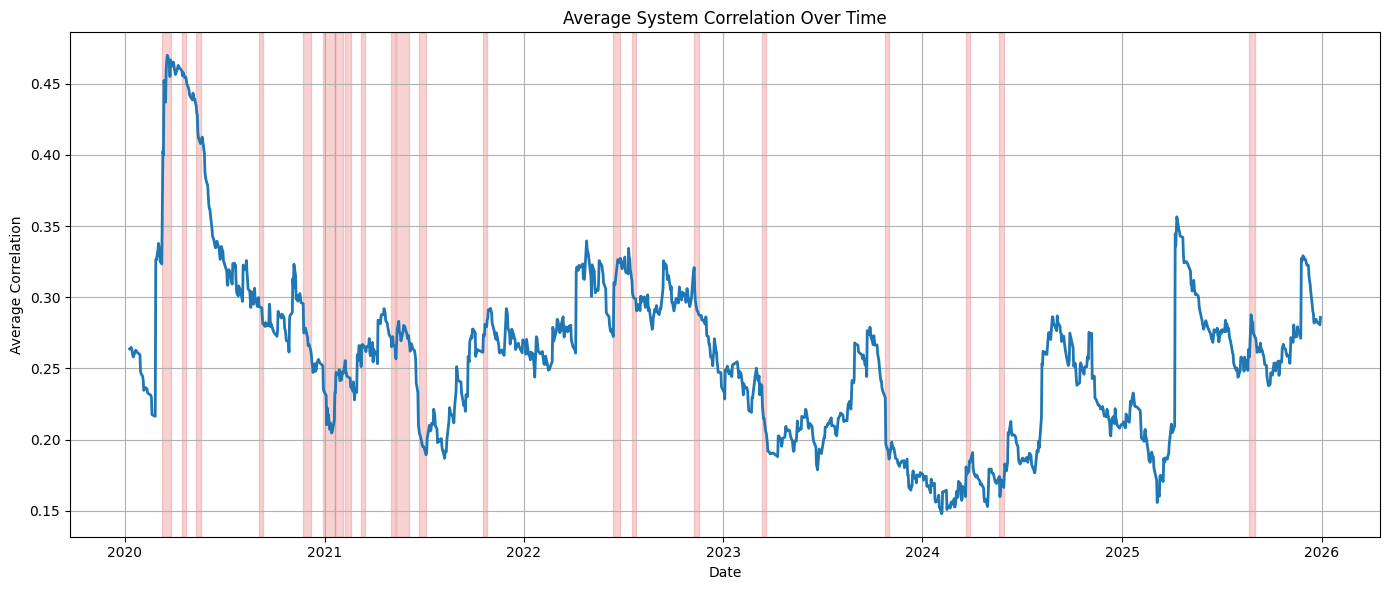

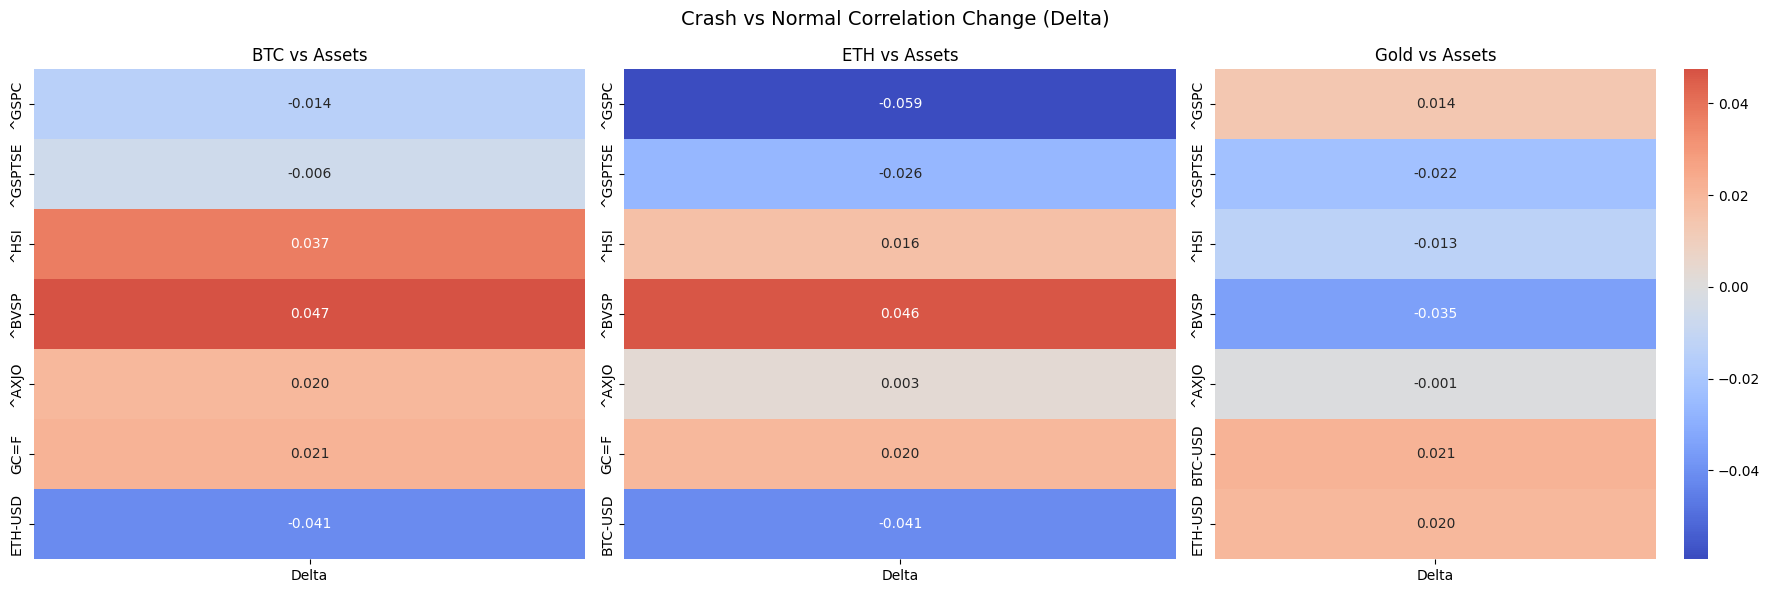

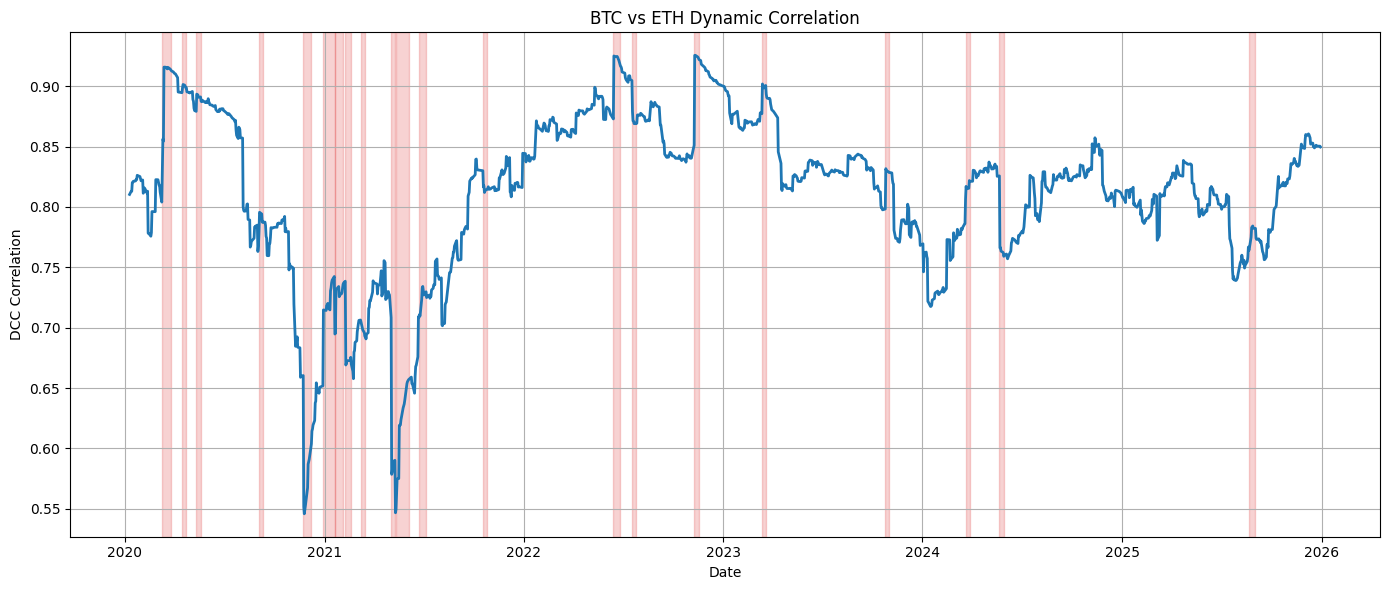

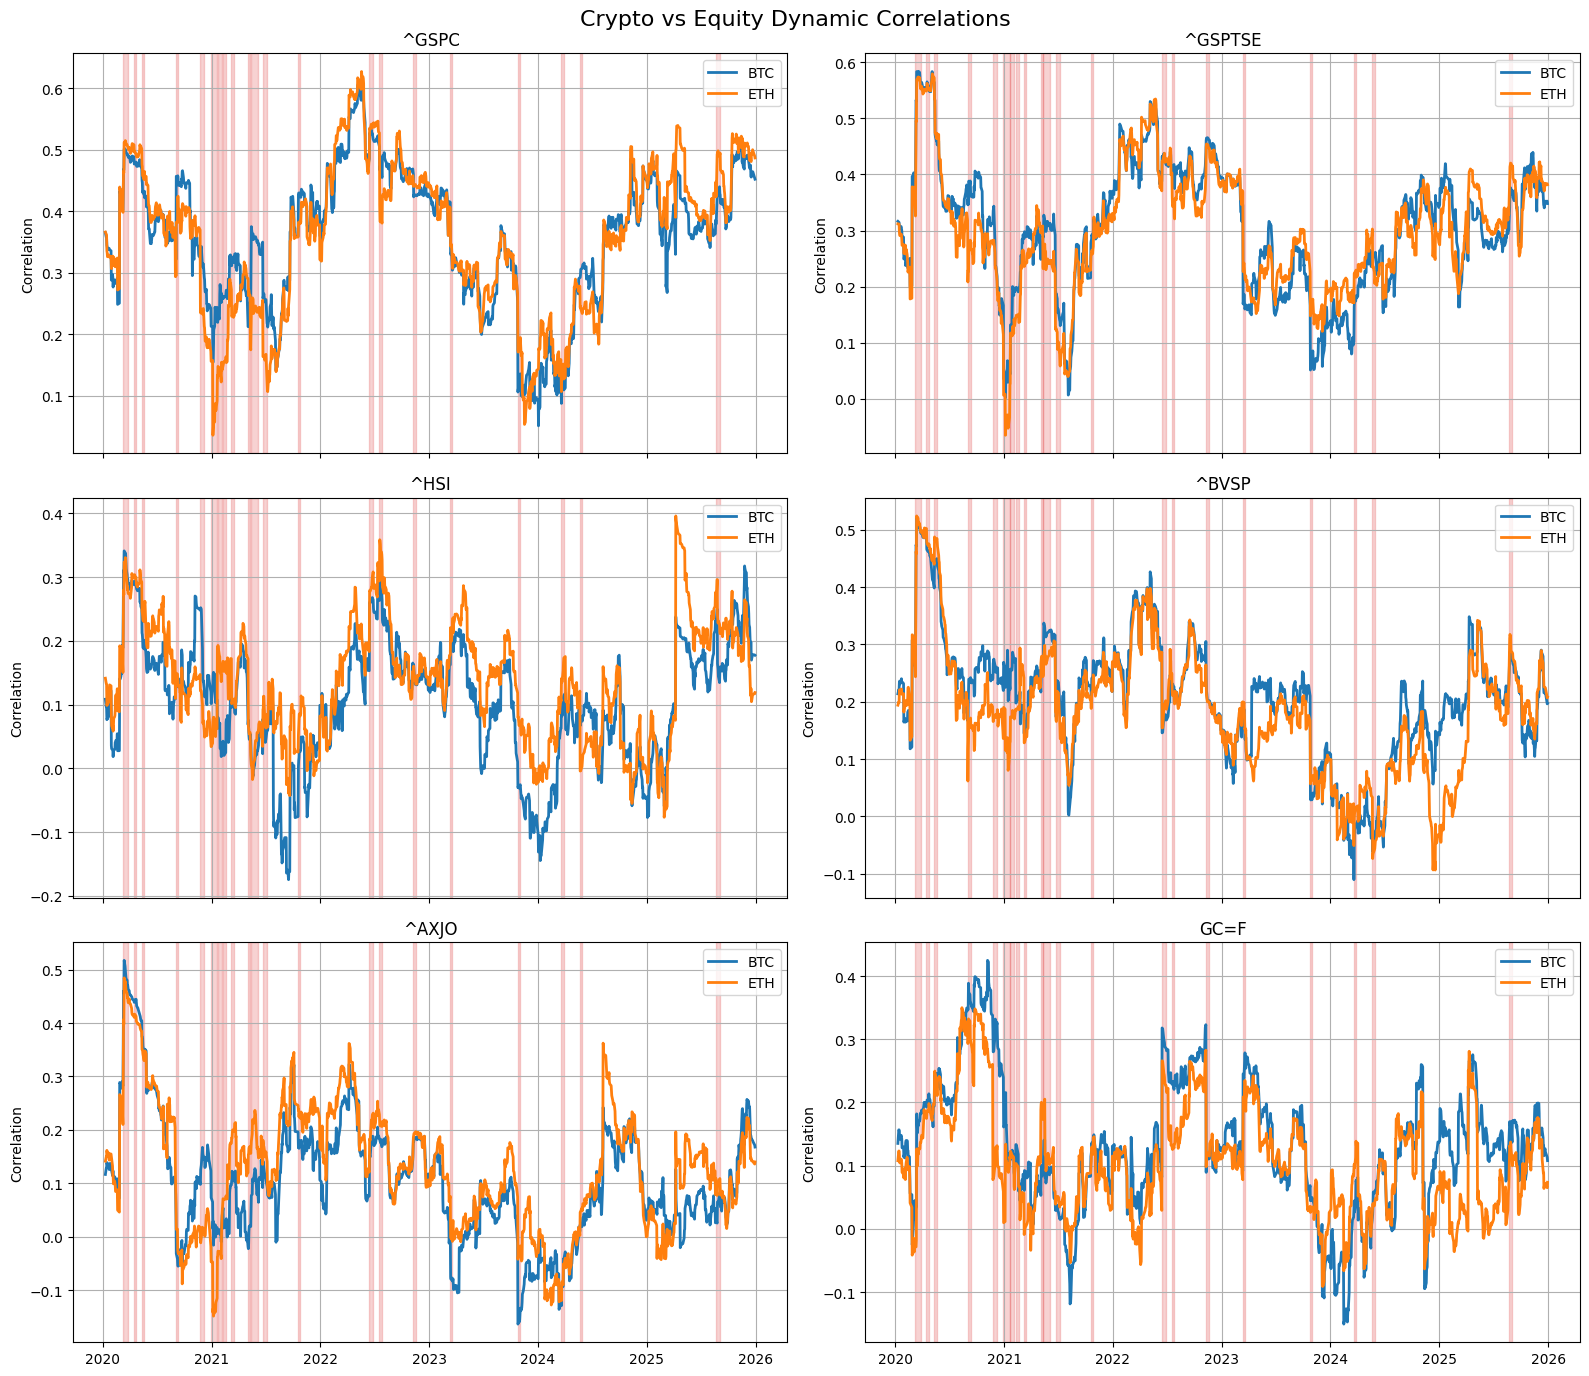

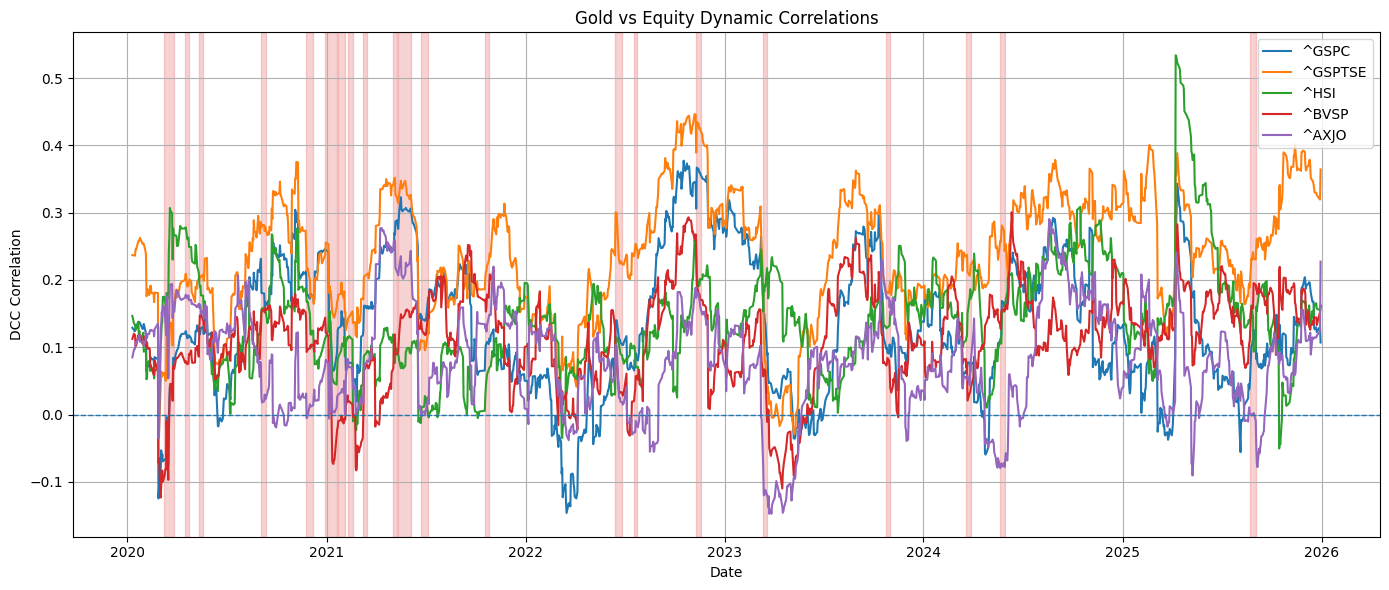

In [4]:
plot_avg_system_correlation()
plot_dcc_delta_heatmaps()
plot_btc_eth_dcc()
plot_crypto_equity_dcc()
plot_gold_safe_haven()